In [8]:
import os
import pickle
import numpy as np

# 1. Create directory for raw data if it doesn't exist (data/raw)
os.makedirs('data/raw', exist_ok=True)

# 2. Generate dummy EEG dataset matching the DEAP structureㅇ
# [40 trials/videos x 40 EEG channels x 8064 time points]
dummy_eeg = np.random.randn(40, 40, 8064)
dummy_eeg = np.random.randn(40, 40, 8064)

# [40 trials x 4 emotion ratings: Valence, Arousal, Dominance, Liking]
dummy_labels = np.random.uniform(1.0, 9.0, (40, 4))

# 3. Save the dataset into 'data/raw/s01.dat' using pickle
dataset = {'data': dummy_eeg, 'labels': dummy_labels}
with open('data/raw/s01.dat', 'wb') as f:
    pickle.dump(dataset, f)

print("s01.dat file successfully generated!")

s01.dat file successfully generated!


In [9]:
import pickle
import numpy as np
import pandas as pd

# 1. Load data file
file_path = 'data/raw/s01.dat'
with open(file_path, 'rb') as f:
    subject_data = pickle.load(f, encoding='latin1')

# 2. Separate EEG signals and emotion labels
eeg_signals = subject_data['data']
labels = subject_data['labels']

# 3. Print out the data shapes for verification
print("EEG signal shape (Trials, Channels, Time-points):", eeg_signals.shape)
print("Emotion labels shape (Trials, Labels):", labels.shape)

EEG signal shape (Trials, Channels, Time-points): (40, 40, 8064)
Emotion labels shape (Trials, Labels): (40, 4)


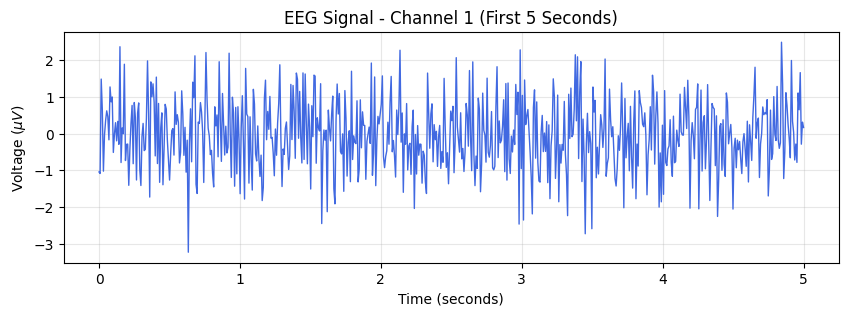

Valence Score: 2.75 / 9.0
Arousal Score: 6.11 / 9.0


In [10]:
import matplotlib.pyplot as plt

# Extract the first 5 seconds of the 1st trial and 1st channel
# Sampling rate is 128Hz, so 5 seconds = 640 data points
time_axis = np.linspace(0, 5, 128 * 5)
sample_signal = eeg_signals[0, 0, :128 * 5]

# Plotting the EEG signal waveform
plt.figure(figsize=(10, 3))
plt.plot(time_axis, sample_signal, color='royalblue', linewidth=1)
plt.title("EEG Signal - Channel 1 (First 5 Seconds)")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage ($\mu V$)")
plt.grid(True, alpha=0.3)
plt.show()

# Print the corresponding emotion evaluation scores for the 1st trial
print(f"Valence Score: {labels[0, 0]:.2f} / 9.0")
print(f"Arousal Score: {labels[0, 1]:.2f} / 9.0")